## Libraries

In [1]:
import os
import glob
import warnings
from tqdm import tqdm_notebook as tqdm
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import geopandas as gpd
from osgeo import gdal
import xarray as xr
import rioxarray as rxr
import rasterio
from rasterio.warp import reproject, Resampling, calculate_default_transform
from matplotlib import pyplot as plt
import seaborn as sns
%matplotlib inline
from tqdm import tqdm_notebook as tqdm
import json 

## Data processing

In [3]:
import re
def insert_space(text):
    return re.sub(r'([a-z](?=[A-Z])|[A-Z](?=[A-Z][a-z]))', r'\1 ', text)

poly = gpd.read_file('D:\Work\ADB\SAR\shapefiles\gadm41_VNM_1.json')
poly['VARNAME_1'] = poly['VARNAME_1'].apply(insert_space)
poly

,GID_1,GID_0,COUNTRY,NAME_1,VARNAME_1,NL_NAME_1,TYPE_1,ENGTYPE_1,CC_1,HASC_1,ISO_1,geometry
0,VNM.1_1,VNM,Vietnam,AnGiang,An Giang,NA,Tỉnh,Province,NA,VN.AG,VN-44,"MULTIPOLYGON (((105.54860 10.42950, 105.54950 ..."
1,VNM.7_1,VNM,Vietnam,BàRịa-VũngTàu,Ba Ria-Vung Tau,NA,Tỉnh,Province,NA,VN.BV,NA,"MULTIPOLYGON (((107.09010 10.32400, 107.08890 ..."
2,VNM.3_1,VNM,Vietnam,BắcGiang,Bac Giang,NA,Tỉnh,Province,NA,VN.BG,NA,"MULTIPOLYGON (((106.28380 21.13230, 106.27340 ..."
3,VNM.4_1,VNM,Vietnam,BắcKạn,Bac Kan,NA,Tỉnh,Province,NA,VN.BK,NA,"MULTIPOLYGON (((105.87240 21.85580, 105.86290 ..."
4,VNM.2_1,VNM,Vietnam,BạcLiêu,Bac Lieu,NA,Tỉnh,Province,NA,VN.BL,NA,"MULTIPOLYGON (((105.42440 9.02130, 105.41640 9..."
...,...,...,...,...,...,...,...,...,...,...,...,...
58,VNM.59_1,VNM,Vietnam,TràVinh,Tra Vinh,NA,Tỉnh,Province,NA,VN.TV,NA,"MULTIPOLYGON (((106.41350 9.52920, 106.40880 9..."
59,VNM.60_1,VNM,Vietnam,TuyênQuang,Tuyen Quang,NA,Tỉnh,Province,NA,VN.TQ,NA,"MULTIPOLYGON (((105.51040 21.60470, 105.51410 ..."
60,VNM.61_1,VNM,Vietnam,VĩnhLong,Vinh Long,NA,Tỉnh,Province,NA,VN.VL,NA,"MULTIPOLYGON (((106.06320 9.94750, 106.06270 9..."
61,VNM.62_1,VNM,Vietnam,VĩnhPhúc,Vinh Phuc,NA,Tỉnh,Province,NA,VN.VC,NA,"MULTIPOLYGON (((105.57130 21.16150, 105.53360 ..."


In [5]:
season = 'early_spring'

paths = glob.glob(f'D:\Work\ADB\SAR\datasets/seasonal_s2/{season}/*.json')
paths

['D:\\Work\\ADB\\SAR\\datasets/seasonal_s2/early_spring\\VNM.10_1_2016.json',
 'D:\\Work\\ADB\\SAR\\datasets/seasonal_s2/early_spring\\VNM.10_1_2017.json',
 'D:\\Work\\ADB\\SAR\\datasets/seasonal_s2/early_spring\\VNM.10_1_2018.json',
 'D:\\Work\\ADB\\SAR\\datasets/seasonal_s2/early_spring\\VNM.10_1_2019.json',
 'D:\\Work\\ADB\\SAR\\datasets/seasonal_s2/early_spring\\VNM.10_1_2020.json',
 'D:\\Work\\ADB\\SAR\\datasets/seasonal_s2/early_spring\\VNM.10_1_2021.json',
 'D:\\Work\\ADB\\SAR\\datasets/seasonal_s2/early_spring\\VNM.10_1_2022.json',
 'D:\\Work\\ADB\\SAR\\datasets/seasonal_s2/early_spring\\VNM.11_1_2016.json',
 'D:\\Work\\ADB\\SAR\\datasets/seasonal_s2/early_spring\\VNM.11_1_2017.json',
 'D:\\Work\\ADB\\SAR\\datasets/seasonal_s2/early_spring\\VNM.11_1_2018.json',
 'D:\\Work\\ADB\\SAR\\datasets/seasonal_s2/early_spring\\VNM.11_1_2019.json',
 'D:\\Work\\ADB\\SAR\\datasets/seasonal_s2/early_spring\\VNM.11_1_2020.json',
 'D:\\Work\\ADB\\SAR\\datasets/seasonal_s2/early_spring\\VNM.11_

In [3]:

def preprocess_ee(season):

    file_paths = glob.glob(f'D:\Work\ADB\SAR\datasets/seasonal_s2/{season}/*.json')
    assert len(file_paths) > 0

    list_gid_1 = []
    list_date = []
    list_ndvi = []
    list_lai = []

    

    for path in tqdm(file_paths):
        with open(path, 'r') as in_file:
            j = json.load(in_file)
        list_gid_1.append(j['province_id'])
        list_date.append(j['date'])
        list_ndvi.append(j['NDVI_mean'])
        list_lai.append(j['LAI_mean'])


    df = pd.DataFrame({'GID_1': list_gid_1,
                    'date': list_date,
                    'NDVI_mean': list_ndvi,
                    'LAI_mean': list_lai})
    
    df = df.sort_values(by=['GID_1', 'date'])
    df = pd.merge(df, poly[['GID_1', 'VARNAME_1']], on=['GID_1'], how='left')
    df = df.rename({'VARNAME_1': 'Province'}, axis=1)
    df['year'] = df['date'].str[:4]
    df['year'] = df['year'].astype(int)
    df = df.groupby(['Province', 'year']).agg({'NDVI_mean': 'mean', 
                                               'LAI_mean': 'mean'}).reset_index()
    
    df['NDVI_mean'] = df['NDVI_mean'].clip(-1, 1)
    df['LAI_mean'] = df['LAI_mean'].clip(0, 3.5)

    df['season'] = season
    return df


In [4]:
ep_df = preprocess_ee('early_spring')
lp_df = preprocess_ee('late_spring')
ma_df = preprocess_ee('main_autumn')
la_df = preprocess_ee('late_autumn')
w_df = preprocess_ee('winter')

  0%|          | 0/441 [00:00<?, ?it/s]

  0%|          | 0/441 [00:00<?, ?it/s]

  0%|          | 0/441 [00:00<?, ?it/s]

  0%|          | 0/441 [00:00<?, ?it/s]

  0%|          | 0/441 [00:00<?, ?it/s]

In [6]:
p_df = pd.concat([ep_df, lp_df], axis=0).reset_index(drop=True)
p_df = p_df.groupby(['Province', 'year']).agg({'NDVI_mean': 'mean',
                                               'LAI_mean': 'mean'}).reset_index()
p_df['season'] = 'spring'

a_df = pd.concat([ma_df, la_df], axis=0).reset_index(drop=True)
a_df = a_df.groupby(['Province', 'year']).agg({'NDVI_mean': 'mean',
                                               'LAI_mean': 'mean'}).reset_index()
a_df['season'] = 'autumn'

all_df = pd.concat([ep_df, lp_df, ma_df, la_df, w_df], axis=0).reset_index(drop=True)
all_df = all_df.groupby(['Province', 'year']).agg({'NDVI_mean': 'mean',
                                               'LAI_mean': 'mean'}).reset_index()
all_df['season'] = 'all'


In [4]:
paths = glob.glob(f'D:\Work\ADB\SAR\datasets/EY/square_2w/*.json')

In [5]:
situ = pd.read_csv('datasets/Crop_Yield_Data_challenge_2.csv')
situ['id'] = situ.index.astype('str')
situ

,District,Latitude,Longitude,"Season(SA = Summer Autumn, WS = Winter Spring)","Rice Crop Intensity(D=Double, T=Triple)",Date of Harvest,Field size (ha),Rice Yield (kg/ha),id
0,Chau_Phu,10.510542,105.248554,SA,T,15-07-2022,3.40,5500,0
1,Chau_Phu,10.509150,105.265098,SA,T,15-07-2022,2.43,6000,1
2,Chau_Phu,10.467721,105.192464,SA,D,15-07-2022,1.95,6400,2
3,Chau_Phu,10.494453,105.241281,SA,T,15-07-2022,4.30,6000,3
4,Chau_Phu,10.535058,105.252744,SA,D,14-07-2022,3.30,6400,4
...,...,...,...,...,...,...,...,...,...
552,Thoai_Son,10.364419,105.164984,WS,T,12-04-2022,7.80,6640,552
553,Thoai_Son,10.358094,105.189541,WS,T,12-04-2022,2.00,7200,553
554,Thoai_Son,10.368014,105.238516,WS,T,12-04-2022,6.20,7200,554
555,Thoai_Son,10.275419,105.234563,WS,T,20-04-2022,3.00,6400,555


In [12]:
with open(paths[0], 'r') as in_file:
    j = json.load(in_file)

j

{'DPRVI_max': 1,
 'DPRVI_mean': 0.6458230502123885,
 'DPRVI_median': 0.6464836799989642,
 'DPRVI_min': 0.17320860553508904,
 'DPRVI_stdDev': 0.16167693938246652,
 'LAI_max': 3.843721375487084,
 'LAI_mean': 1.7491011002077417,
 'LAI_median': 1.742707298459722,
 'LAI_min': 0.9595290233394685,
 'LAI_stdDev': 0.39399904393790025,
 'NDVI_max': 0.3903093934059143,
 'NDVI_mean': 0.31027210795422727,
 'NDVI_median': 0.32474304454554725,
 'NDVI_min': 0.18380887806415558,
 'NDVI_stdDev': 0.04651999680802271,
 'RVI_max': 2.148374654106526,
 'RVI_mean': 1.072036111088746,
 'RVI_median': 1.0434401133799431,
 'RVI_min': 0.24059224547743074,
 'RVI_stdDev': 0.34005036364951086,
 'VHVV_max': 1.160264228868535,
 'VHVV_mean': 0.3858989753887015,
 'VHVV_median': 0.35522683865332466,
 'VHVV_min': 0.0639973796904574,
 'VHVV_stdDev': 0.17209461974568652,
 'VH_max': 0.08748740515635303,
 'VH_mean': 0.03487996623540472,
 'VH_median': 0.03287901622788983,
 'VH_min': 0.008106735526541679,
 'VH_stdDev': 0.0123007

In [15]:
df = pd.json_normalize(j)
df = df.drop([col for col in df.columns if 'angle' in col], axis=1)
df

,DPRVI_max,DPRVI_mean,DPRVI_median,DPRVI_min,DPRVI_stdDev,LAI_max,LAI_mean,LAI_median,LAI_min,LAI_stdDev,...,VVVH_median,VVVH_min,VVVH_stdDev,VV_max,VV_mean,VV_median,VV_min,VV_stdDev,id,date
0,1,0.645823,0.646484,0.173209,0.161677,3.843721,1.749101,1.742707,0.959529,0.393999,...,2.846437,0.861873,1.801998,0.287843,0.102058,0.094764,0.018075,0.04204,0,15-07-2022


In [21]:
'square_2w'[7]

'2'

In [25]:
def preprocess_situ(type):

    file_paths = glob.glob(f'D:\Work\ADB\SAR\datasets/EY/{type}/*.json')
    assert len(file_paths) > 0

    list_dfs = []

    for path in tqdm(file_paths):
        with open(path, 'r') as in_file:
            j = json.load(in_file)
        df_j = pd.json_normalize(j)
        df_j = df_j.drop([col for col in df_j.columns if 'angle' in col], axis=1)
        list_dfs.append(df_j)


    df = pd.concat(list_dfs, axis=0).reset_index(drop=True)

    cols_ndvi = [col for col in df.columns if 'NDVI' in col]
    cols_lai = [col for col in df.columns if 'LAI' in col]
    
    for col in cols_ndvi:
        df[col] = df[col].clip(-1, 1)

    for col in cols_lai:
        df[col] = df[col].clip(0, 3.5)
    
    df = pd.merge(situ, df, on=['id'], how='inner')
    df['days_lookback'] = int(type[7])*7
    df = df.drop(['date'], axis=1)

    return df


In [26]:
# circle = preprocess_situ('circle')
# circle_mask = preprocess_situ('circle_mask')
# square = preprocess_situ('square')
# square_mask = preprocess_situ('square_mask')

df_2w = preprocess_situ('square_2w')
df_3w = preprocess_situ('square_3w')
df_4w = preprocess_situ('square_4w')


  0%|          | 0/557 [00:00<?, ?it/s]

  0%|          | 0/557 [00:00<?, ?it/s]

  0%|          | 0/557 [00:00<?, ?it/s]

In [27]:
df_4w

,District,Latitude,Longitude,"Season(SA = Summer Autumn, WS = Winter Spring)","Rice Crop Intensity(D=Double, T=Triple)",Date of Harvest,Field size (ha),Rice Yield (kg/ha),id,DPRVI_max,...,VVVH_mean,VVVH_median,VVVH_min,VVVH_stdDev,VV_max,VV_mean,VV_median,VV_min,VV_stdDev,days_lookback
0,Chau_Phu,10.510542,105.248554,SA,T,15-07-2022,3.40,5500,0,0.989495,...,3.200803,3.091929,0.859941,1.283987,0.233426,0.085951,0.070741,0.025453,0.041061,28
1,Chau_Phu,10.509150,105.265098,SA,T,15-07-2022,2.43,6000,1,1.000000,...,3.128331,2.532007,0.889955,1.910115,0.320671,0.093907,0.071309,0.025414,0.056711,28
2,Chau_Phu,10.467721,105.192464,SA,D,15-07-2022,1.95,6400,2,0.958729,...,3.316736,3.033911,1.113663,1.365649,0.208705,0.092512,0.082553,0.032495,0.037127,28
3,Chau_Phu,10.494453,105.241281,SA,T,15-07-2022,4.30,6000,3,0.928591,...,3.336129,3.093887,1.249231,1.333660,0.272372,0.100279,0.093317,0.031860,0.036278,28
4,Chau_Phu,10.535058,105.252744,SA,D,14-07-2022,3.30,6400,4,0.999192,...,2.568599,2.422490,0.941132,0.817674,0.223764,0.085674,0.081556,0.031803,0.025953,28
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
552,Thoai_Son,10.364419,105.164984,WS,T,12-04-2022,7.80,6640,552,0.986454,...,3.674257,3.469175,1.054230,1.345884,0.298801,0.100589,0.092721,0.030020,0.038343,28
553,Thoai_Son,10.358094,105.189541,WS,T,12-04-2022,2.00,7200,553,0.898514,...,3.987892,3.584780,1.423804,1.547129,0.259226,0.121754,0.111789,0.046687,0.042103,28
554,Thoai_Son,10.368014,105.238516,WS,T,12-04-2022,6.20,7200,554,0.946851,...,3.859366,3.401378,1.167885,1.765665,3.740066,0.202223,0.164403,0.080465,0.215489,28
555,Thoai_Son,10.275419,105.234563,WS,T,20-04-2022,3.00,6400,555,0.688904,...,10.272127,9.121329,2.555811,4.971318,0.450522,0.176855,0.167269,0.070835,0.053834,28


In [28]:
df_2w.to_csv(f'D:\Work\ADB\SAR\datasets/EY_2_weeks.csv', index=False)
df_3w.to_csv(f'D:\Work\ADB\SAR\datasets/EY_3_weeks.csv', index=False)
df_4w.to_csv(f'D:\Work\ADB\SAR\datasets/EY_4_weeks.csv', index=False)


In [58]:
circle.to_csv(f'D:\Work\ADB\SAR\datasets/EY_insitu_circle_plot.csv', index=False)
square.to_csv(f'D:\Work\ADB\SAR\datasets/EY_insitu_square_plot.csv', index=False)

In [214]:
# df = pd.read_csv('datasets/provincial_SAR.csv')
# df = pd.merge(df, poly[['GID_1', 'VARNAME_1']], on=['GID_1'], how='left')
# df = df.rename({'VARNAME_1': 'Province'}, axis=1)
# df['year'] = df['date'].str[:4]
# df['year'] = df['year'].astype(int)
# df = df.groupby(['Province', 'year']).agg({'DPRVI_mean': 'mean', 
#                                            'RVI_mean': 'mean',
#                                            'VH': 'mean',
#                                            'VV': 'mean',
#                                            'VHVV_mean': 'mean',
#                                            'VVVH_mean': 'mean'}).reset_index()
# df

In [3]:
# spring_prod = pd.read_excel('D:\Work\ADB\SAR\datasets\Spring paddy production.xlsx')
# spring_prod = pd.melt(spring_prod, id_vars=['Province'], 
#                       var_name='year', 
#                       value_vars=spring_prod.columns.to_list()[1:], 
#                       value_name='spring_production')
# spring_prod

In [12]:
spring_yield = pd.read_excel('D:\Work\ADB\SAR\datasets\Spring paddy yield.xlsx')
spring_yield = pd.melt(spring_yield, 
                       id_vars=['Province'], 
                       var_name='year', 
                       value_vars=spring_yield.columns.to_list()[1:], 
                       value_name='spring_yield')
spring_yield['year'] = spring_yield['year'].astype(int)

total_yield = pd.read_excel('D:\Work\ADB\SAR\datasets\Total paddy yield.xlsx')
total_yield = pd.melt(total_yield, 
                      id_vars=['Province'], 
                      var_name='year', 
                      value_vars=total_yield.columns.to_list()[1:], 
                      value_name='total_yield')
total_yield['year'] = total_yield['year'].astype(int)

winter_yield = pd.read_excel('D:\Work\ADB\SAR\datasets\Winter paddy yield.xlsx')
winter_yield = pd.melt(winter_yield, 
                       id_vars=['Province'], 
                       var_name='year', 
                       value_vars=winter_yield.columns.to_list()[1:], 
                       value_name='winter_yield')
winter_yield['year'] = winter_yield['year'].astype(int)

autumn_yield = pd.read_excel('D:\Work\ADB\SAR\datasets\Autumn paddy yield.xlsx')
autumn_yield = pd.melt(autumn_yield, 
                      id_vars=['Province'], 
                      var_name='year', 
                      value_vars=autumn_yield.columns.to_list()[1:], 
                      value_name='autumn_yield')

In [13]:
df_spring = pd.merge(spring_yield, p_df, on=['Province', 'year'], how='inner')
df_spring

,Province,year,spring_yield,NDVI_mean,LAI_mean,season
0,Ha Noi,2016,60.9,0.254127,0.823167,spring
1,Vinh Phuc,2016,58.6,0.342175,1.372339,spring
2,Bac Ninh,2016,65.0,0.034801,0.338341,spring
3,Quang Ninh,2016,54.4,0.197903,0.604061,spring
4,Hai Duong,2016,64.6,0.048906,0.374033,spring
...,...,...,...,...,...,...
422,Can Tho,2022,74.2,0.100598,0.314180,spring
423,Hau Giang,2022,77.8,0.238522,0.834253,spring
424,Soc Trang,2022,67.1,0.100024,0.351862,spring
425,Bac Lieu,2022,75.7,0.105605,0.323727,spring


In [14]:
df_autumn = pd.merge(autumn_yield, a_df, on=['Province', 'year'], how='inner')
df_autumn

,Province,year,autumn_yield,NDVI_mean,LAI_mean,season
0,Nghe An,2016,49.5,0.181196,0.731291,autumn
1,Ha Tinh,2016,45.4,0.206149,0.747925,autumn
2,Quang Binh,2016,41.0,0.171695,2.024293,autumn
3,Quang Tri,2016,51.8,0.276327,1.065951,autumn
4,Thua Thien Hue,2016,59.2,0.212035,0.682129,autumn
...,...,...,...,...,...,...
205,Can Tho,2022,57.2,0.165713,0.643241,autumn
206,Hau Giang,2022,58.9,0.231090,0.860064,autumn
207,Soc Trang,2022,54.7,0.211721,0.665957,autumn
208,Bac Lieu,2022,58.6,0.227415,0.922485,autumn


In [15]:
df_winter = pd.merge(winter_yield, w_df, on=['Province', 'year'], how='inner')
df_winter

,Province,year,winter_yield,NDVI_mean,LAI_mean,season
0,Ha Noi,2016,51.6,0.364874,1.147018,winter
1,Vinh Phuc,2016,41.1,0.271694,0.967005,winter
2,Bac Ninh,2016,59.0,0.093550,0.472116,winter
3,Quang Ninh,2016,47.2,0.245534,0.932132,winter
4,Hai Duong,2016,56.1,0.022735,0.000000,winter
...,...,...,...,...,...,...
422,Can Tho,2022,NaN,0.148339,0.366590,winter
423,Hau Giang,2022,NaN,0.124674,0.456929,winter
424,Soc Trang,2022,50.9,0.031254,0.000000,winter
425,Bac Lieu,2022,60.7,0.223420,0.669040,winter


In [16]:
df_total = pd.merge(total_yield, all_df, on=['Province', 'year'], how='inner')
df_total

,Province,year,total_yield,NDVI_mean,LAI_mean,season
0,Ha Noi,2016,56.3,0.264185,0.925865,all
1,Vinh Phuc,2016,50.4,0.288486,1.147428,all
2,Bac Ninh,2016,62.0,0.113689,0.502254,all
3,Quang Ninh,2016,50.1,0.212461,0.776852,all
4,Hai Duong,2016,60.4,0.114817,0.543988,all
...,...,...,...,...,...,...
422,Can Tho,2022,63.2,0.136192,0.456286,all
423,Hau Giang,2022,66.6,0.212779,0.769112,all
424,Soc Trang,2022,61.4,0.130949,0.407128,all
425,Bac Lieu,2022,63.4,0.177892,0.632293,all


In [17]:
df_early_spring = pd.merge(spring_yield, ep_df, on=['Province', 'year'], how='inner')
df_early_spring

,Province,year,spring_yield,NDVI_mean,LAI_mean,season
0,Ha Noi,2016,60.9,0.307119,0.972223,early_spring
1,Vinh Phuc,2016,58.6,0.491412,1.923471,early_spring
2,Bac Ninh,2016,65.0,-0.013849,0.000000,early_spring
3,Quang Ninh,2016,54.4,0.214384,0.730416,early_spring
4,Hai Duong,2016,64.6,-0.007388,0.000000,early_spring
...,...,...,...,...,...,...
422,Can Tho,2022,74.2,0.037480,0.000000,early_spring
423,Hau Giang,2022,77.8,0.298125,0.908800,early_spring
424,Soc Trang,2022,67.1,0.012986,0.000000,early_spring
425,Bac Lieu,2022,75.7,0.086769,0.250483,early_spring


In [18]:
df_late_spring = pd.merge(spring_yield, lp_df, on=['Province', 'year'], how='inner')
df_late_spring

,Province,year,spring_yield,NDVI_mean,LAI_mean,season
0,Ha Noi,2016,60.9,0.201134,0.674111,late_spring
1,Vinh Phuc,2016,58.6,0.192937,0.821207,late_spring
2,Bac Ninh,2016,65.0,0.083451,0.676682,late_spring
3,Quang Ninh,2016,54.4,0.181422,0.477705,late_spring
4,Hai Duong,2016,64.6,0.105200,0.748067,late_spring
...,...,...,...,...,...,...
422,Can Tho,2022,74.2,0.163716,0.628359,late_spring
423,Hau Giang,2022,77.8,0.178919,0.759705,late_spring
424,Soc Trang,2022,67.1,0.187062,0.703725,late_spring
425,Bac Lieu,2022,75.7,0.124441,0.396972,late_spring


In [19]:
df_main_autumn = pd.merge(autumn_yield, ma_df, on=['Province', 'year'], how='inner')
df_main_autumn

,Province,year,autumn_yield,NDVI_mean,LAI_mean,season
0,Nghe An,2016,49.5,0.147617,0.697564,main_autumn
1,Ha Tinh,2016,45.4,0.202045,0.706450,main_autumn
2,Quang Binh,2016,41.0,0.172055,0.548586,main_autumn
3,Quang Tri,2016,51.8,0.327048,1.274207,main_autumn
4,Thua Thien Hue,2016,59.2,0.251554,0.795964,main_autumn
...,...,...,...,...,...,...
205,Can Tho,2022,57.2,0.151466,0.697193,main_autumn
206,Hau Giang,2022,58.9,0.264339,0.928088,main_autumn
207,Soc Trang,2022,54.7,0.280074,0.934669,main_autumn
208,Bac Lieu,2022,58.6,0.226640,0.989083,main_autumn


In [20]:
df_late_autumn = pd.merge(autumn_yield, la_df, on=['Province', 'year'], how='inner')
df_late_autumn

,Province,year,autumn_yield,NDVI_mean,LAI_mean,season
0,Nghe An,2016,49.5,0.214775,0.765018,late_autumn
1,Ha Tinh,2016,45.4,0.210254,0.789401,late_autumn
2,Quang Binh,2016,41.0,0.171336,3.500000,late_autumn
3,Quang Tri,2016,51.8,0.225605,0.857696,late_autumn
4,Thua Thien Hue,2016,59.2,0.172516,0.568294,late_autumn
...,...,...,...,...,...,...
205,Can Tho,2022,57.2,0.179961,0.589289,late_autumn
206,Hau Giang,2022,58.9,0.197840,0.792040,late_autumn
207,Soc Trang,2022,54.7,0.143368,0.397246,late_autumn
208,Bac Lieu,2022,58.6,0.228189,0.855887,late_autumn


### ADB

In [11]:
meta = pd.read_csv(r'D:\Work\ADB\SAR\datasets\thai_binh_insitu.csv')
meta

,latitude,longitude,paddy_weight_after_threshing,paddy_weight_after_drying,harvest_date
0,20.621192,106.379849,3967.61,3001.61,5/10/2015
1,20.622097,106.379330,4461.21,3504.88,5/10/2015
2,20.621892,106.380214,4361.34,3376.35,5/10/2015
3,20.622102,106.379718,4100.02,3084.21,5/10/2015
4,20.622102,106.379733,4162.12,3272.97,6/10/2015
...,...,...,...,...,...
251,20.620496,106.185483,4210.50,3334.00,25/9/2015
252,20.625563,106.158519,5513.20,4122.30,25/9/2015
253,20.625591,106.157891,4414.23,3268.96,25/9/2015
254,20.625854,106.158675,4010.40,2875.80,25/9/2015


In [23]:
def preprocess_situ(type):

    file_paths = glob.glob(f'D:\Work\ADB\SAR\datasets/thai_binh/{type}/*.json')
    assert len(file_paths) > 0

    list_dfs = []

    for path in tqdm(file_paths):
        with open(path, 'r') as in_file:
            j = json.load(in_file)
        df_j = pd.json_normalize(j)
        df_j = df_j.drop([col for col in df_j.columns if 'angle' in col], axis=1)
        list_dfs.append(df_j)


    df = pd.concat(list_dfs, axis=0).reset_index(drop=True)

    cols_ndvi = [col for col in df.columns if 'NDVI' in col]
    cols_lai = [col for col in df.columns if 'LAI' in col]
    
    for col in cols_ndvi:
        df[col] = df[col].clip(-1, 1)

    for col in cols_lai:
        df[col] = df[col].clip(0, 3.5)
    
    # df = pd.concat([df, situ])
    df['days_lookback'] = int(type[0])*7
    df = df.drop(['date'], axis=1)

    df = pd.concat([meta, df], axis=1)

    return df

tb_1w = preprocess_situ('1w')
tb_1w.to_csv(f'D:\Work\ADB\SAR\datasets/thai_binh/thai_binh_1w.csv', index=False)
tb_2w = preprocess_situ('2w')
tb_2w.to_csv(f'D:\Work\ADB\SAR\datasets/thai_binh/thai_binh_2w.csv', index=False)
tb_3w = preprocess_situ('3w')
tb_3w.to_csv(f'D:\Work\ADB\SAR\datasets/thai_binh/thai_binh_3w.csv', index=False)
tb_4w = preprocess_situ('4w')
tb_4w.to_csv(f'D:\Work\ADB\SAR\datasets/thai_binh/thai_binh_4w.csv', index=False)
tb_5w = preprocess_situ('5w')
tb_5w.to_csv(f'D:\Work\ADB\SAR\datasets/thai_binh/thai_binh_5w.csv', index=False)
tb_6w = preprocess_situ('6w')
tb_6w.to_csv(f'D:\Work\ADB\SAR\datasets/thai_binh/thai_binh_6w.csv', index=False)

  0%|          | 0/256 [00:00<?, ?it/s]

  0%|          | 0/256 [00:00<?, ?it/s]

  0%|          | 0/256 [00:00<?, ?it/s]

  0%|          | 0/256 [00:00<?, ?it/s]

  0%|          | 0/256 [00:00<?, ?it/s]

  0%|          | 0/256 [00:00<?, ?it/s]

In [25]:

def calculate_null_percentage(df):
    print(len(df[df['DPRVI_mean'].isnull()])/len(df))

calculate_null_percentage(tb_1w)
calculate_null_percentage(tb_2w)
calculate_null_percentage(tb_3w)
calculate_null_percentage(tb_4w)
calculate_null_percentage(tb_5w)
calculate_null_percentage(tb_6w)

0.73828125
0.44140625
0.234375
0.0
0.0
0.0


In [22]:
tb_1w

## EDA

### Spring

In [21]:
df_spring.describe()

,year,spring_yield,NDVI_mean,LAI_mean
count,427.000000,425.000000,427.000000,427.000000
mean,2019.000000,61.289176,0.192526,0.724484
std,2.002346,9.045359,0.094139,0.398779
min,2016.000000,0.400000,0.028234,0.000000
25%,2017.000000,57.200000,0.110711,0.440380
50%,2019.000000,61.500000,0.192083,0.680417
75%,2021.000000,66.800000,0.254337,0.889327
max,2022.000000,78.200000,0.470300,2.027549


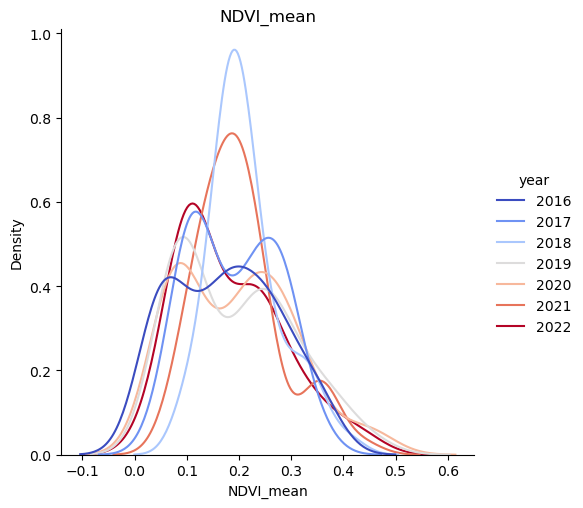

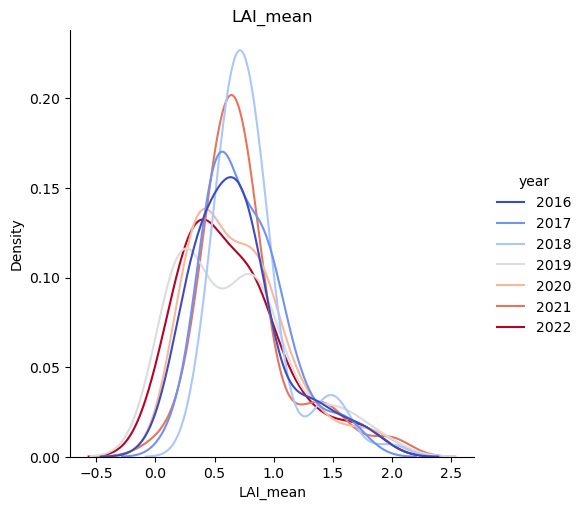

In [22]:
for indicator in ['NDVI_mean', 'LAI_mean']:
    sns.displot(data=df_spring, x=indicator, kind="kde", hue='year', palette='coolwarm')
    plt.title(indicator)

### Autumn

In [23]:
df_autumn.describe()

,autumn_yield,NDVI_mean,LAI_mean
count,196.000000,210.000000,210.000000
mean,53.788776,0.203045,0.778150
std,7.244696,0.052413,0.278876
min,34.000000,0.073057,0.173656
25%,49.650000,0.167974,0.619319
50%,55.150000,0.198894,0.787344
75%,58.125000,0.237758,0.915838
max,73.100000,0.347608,2.221610


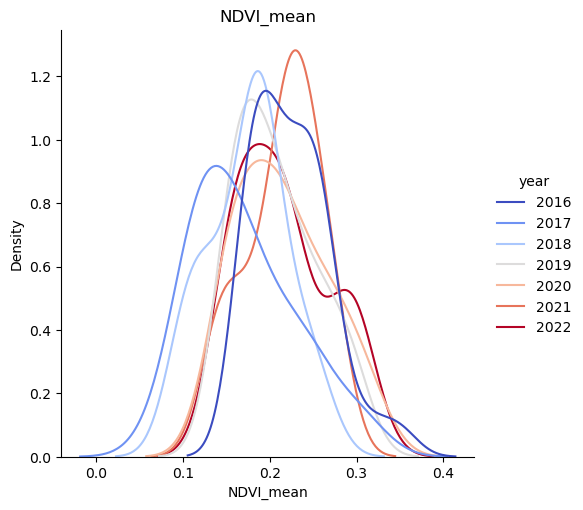

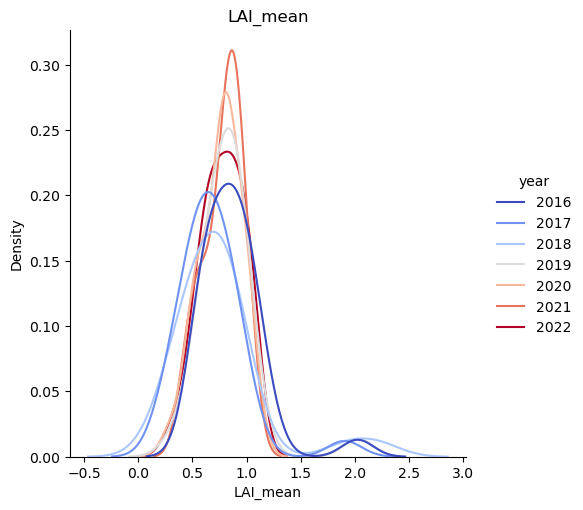

In [24]:
for indicator in ['NDVI_mean', 'LAI_mean']:
    sns.displot(data=df_autumn, x=indicator, kind="kde", hue='year', palette='coolwarm')
    plt.title(indicator)

### Winter

In [25]:
df_winter.describe()

,year,winter_yield,NDVI_mean,LAI_mean
count,427.000000,392.000000,427.000000,427.000000
mean,2019.000000,44.878061,0.145334,0.470654
std,2.002346,12.855324,0.090615,0.436657
min,2016.000000,6.000000,-0.019031,0.000000
25%,2017.000000,37.200000,0.078286,0.137996
50%,2019.000000,48.050000,0.133535,0.424921
75%,2021.000000,54.550000,0.206498,0.709779
max,2022.000000,65.000000,0.471943,3.500000


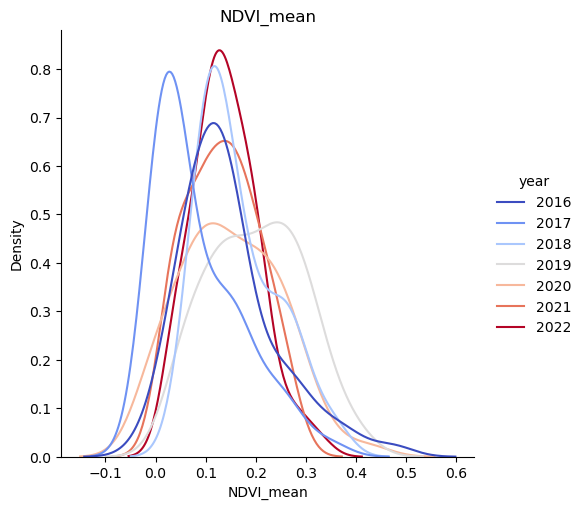

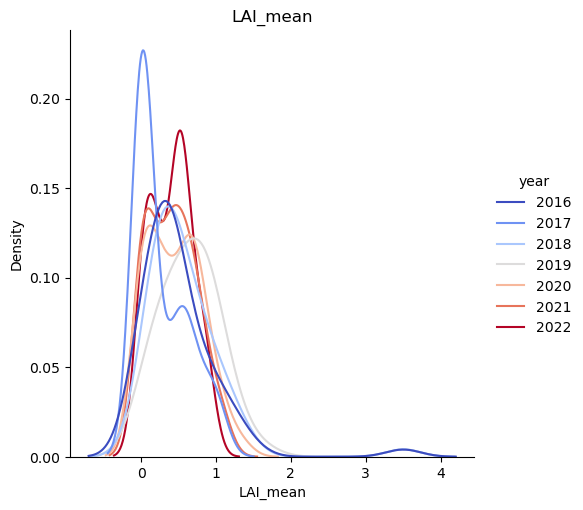

In [26]:
for indicator in ['NDVI_mean', 'LAI_mean']:
    sns.displot(data=df_winter, x=indicator, kind="kde", hue='year', palette='coolwarm')
    plt.title(indicator)

### Total

In [27]:
df_total.describe()

,year,total_yield,NDVI_mean,LAI_mean
count,427.000000,427.000000,427.000000,427.000000
mean,2019.000000,55.107963,0.185841,0.700177
std,2.002346,8.166396,0.052165,0.266023
min,2016.000000,21.100000,0.068056,0.195507
25%,2017.000000,51.200000,0.142674,0.504385
50%,2019.000000,56.900000,0.186610,0.667277
75%,2021.000000,60.700000,0.224774,0.847191
max,2022.000000,71.200000,0.307358,2.184588


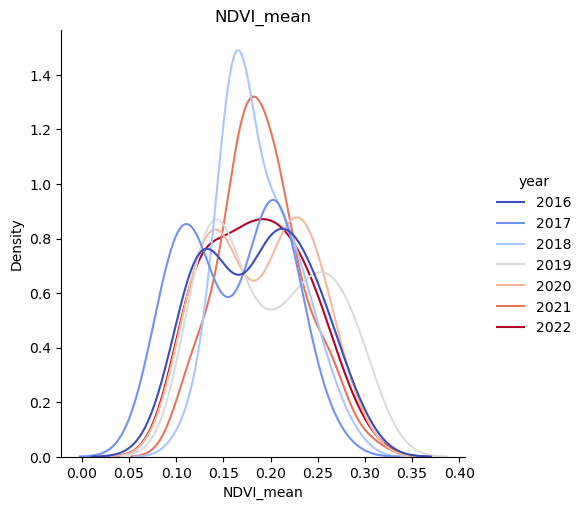

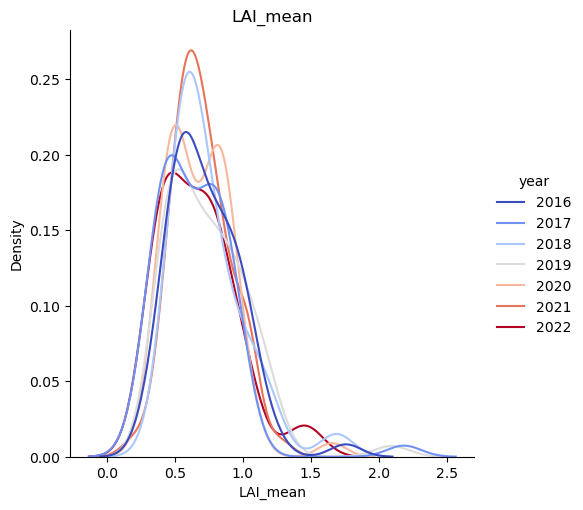

In [28]:
for indicator in ['NDVI_mean', 'LAI_mean']:
    sns.displot(data=df_total, x=indicator, kind="kde", hue='year', palette='coolwarm')
    plt.title(indicator)

## EY

### Circle

In [29]:
circle.describe()

,Latitude,Longitude,Field size (ha),Rice Yield (kg/ha),NDVI_mean,LAI_mean,RVI_mean,DPRVI_mean,VHVV_mean,VVVH_mean,VV,VH
count,557.000000,557.000000,557.000000,557.000000,557.000000,557.000000,449.000000,449.000000,449.000000,449.000000,449.000000,449.000000
mean,10.418423,105.221984,2.666732,6631.310592,0.183462,0.677171,0.802839,0.514298,0.257973,4.881383,0.152684,0.038711
std,0.107198,0.078292,1.246411,795.533782,0.110466,0.477061,0.214087,0.122322,0.080757,3.122640,0.059156,0.016961
min,10.195117,105.075243,1.200000,5200.000000,-0.022026,0.000000,0.162923,0.118263,0.042808,2.294930,0.039609,0.003672
25%,10.334417,105.160660,1.800000,6000.000000,0.098325,0.311887,0.663634,0.442479,0.201206,3.159772,0.106886,0.027391
50%,10.412537,105.208993,2.200000,6500.000000,0.165265,0.606954,0.843334,0.542742,0.269594,3.803368,0.147324,0.037400
75%,10.494104,105.275589,3.200000,7200.000000,0.258925,0.996274,0.971184,0.609073,0.322134,5.289076,0.189021,0.049155
max,10.676956,105.424059,9.000000,8000.000000,0.509646,3.500000,1.217553,0.727340,0.438344,29.137224,0.590093,0.091149


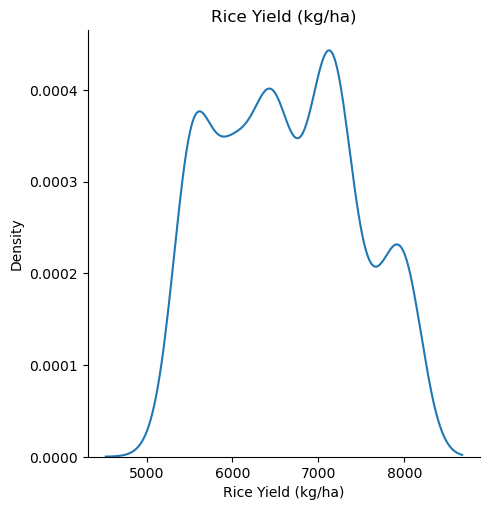

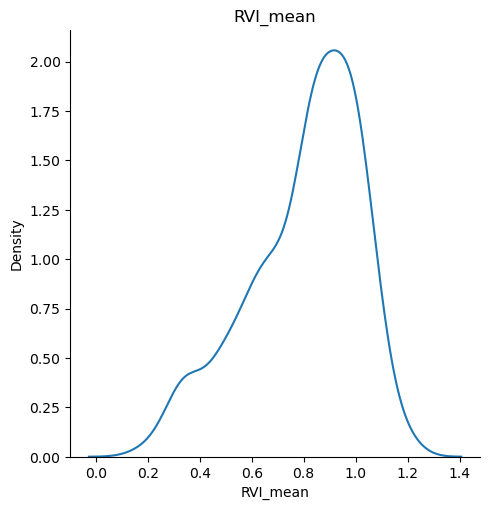

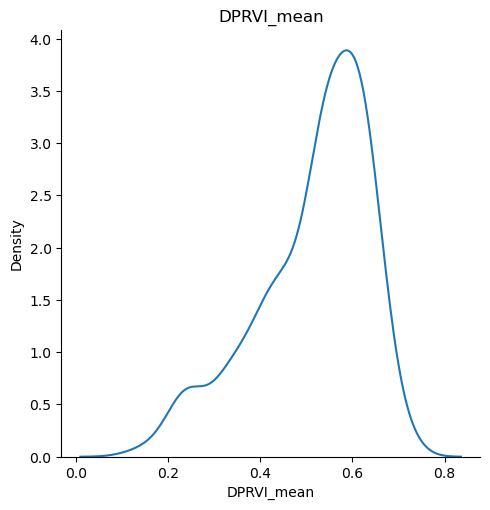

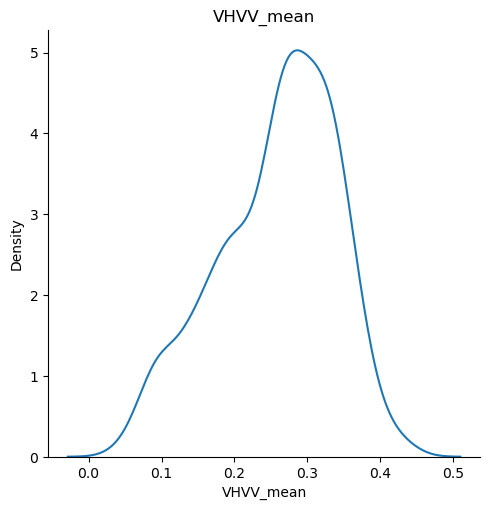

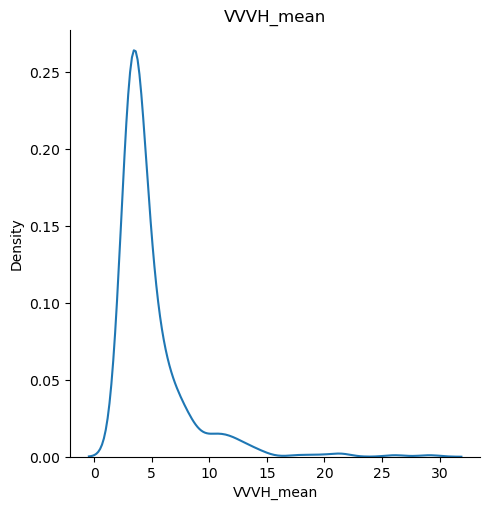

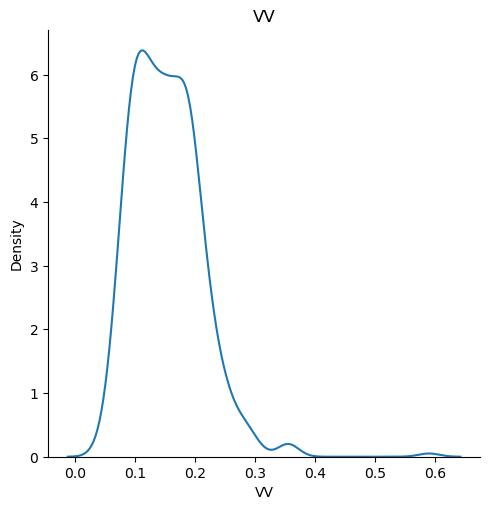

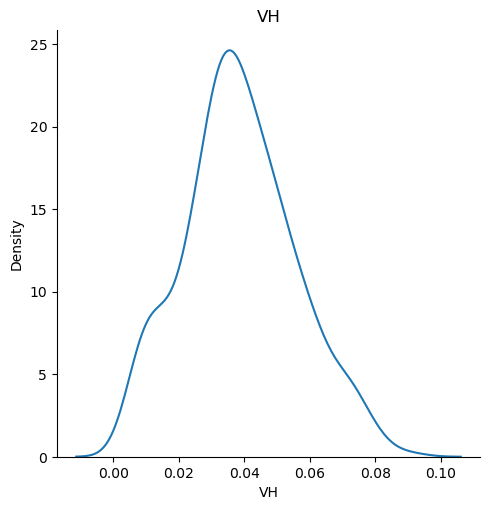

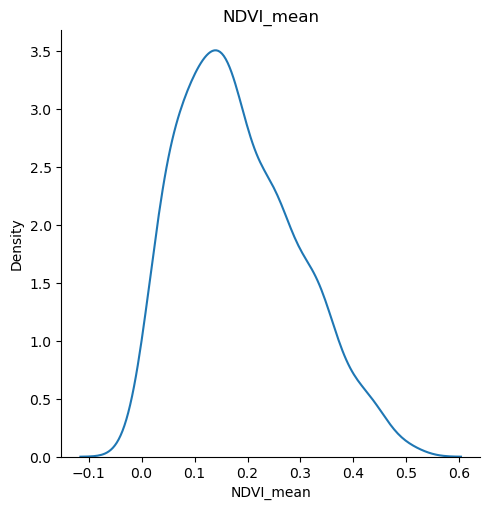

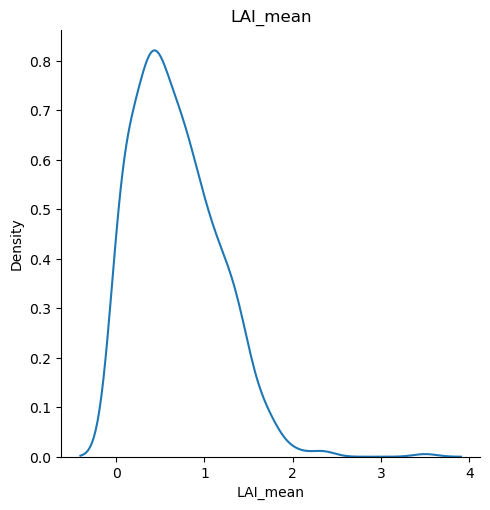

In [30]:
# fig, axes = plt.subplots(2 ,5, figsize=(30, 8))
# sns.displot(data=circle, x=indicator, kind="kde")

for indicator in ['Rice Yield (kg/ha)', 'RVI_mean', 'DPRVI_mean', 'VHVV_mean', 'VVVH_mean', 'VV', 'VH', 'NDVI_mean', 'LAI_mean']:
    sns.displot(data=circle, x=indicator, kind="kde", palette='coolwarm')
    plt.title(indicator)

### Circle masked

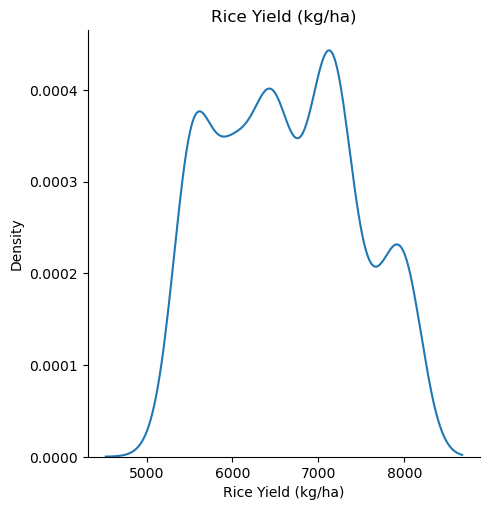

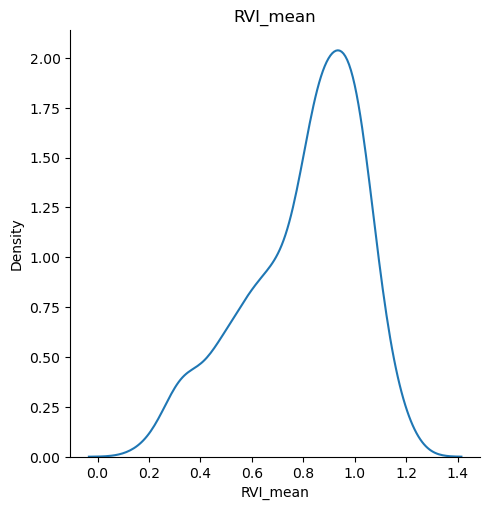

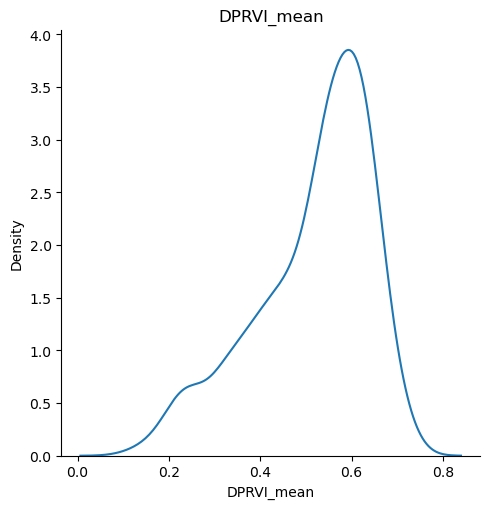

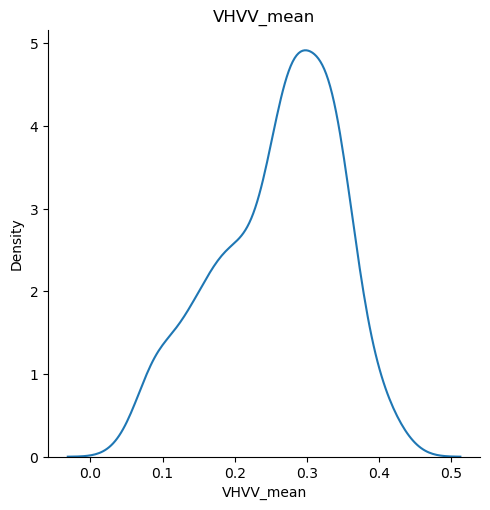

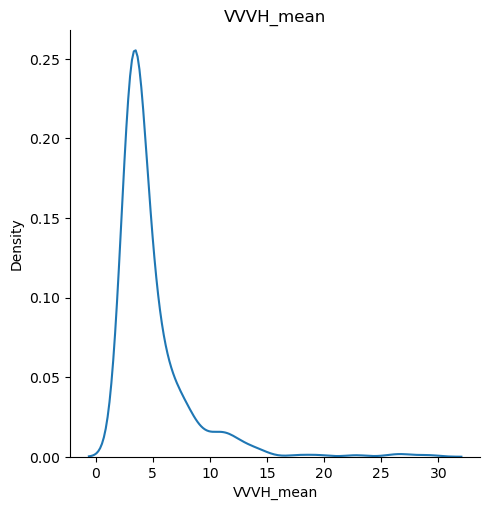

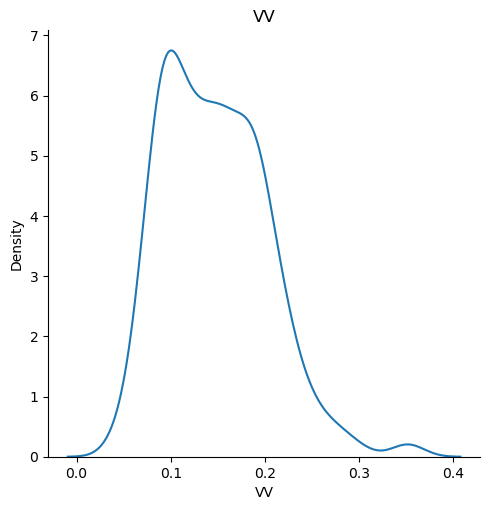

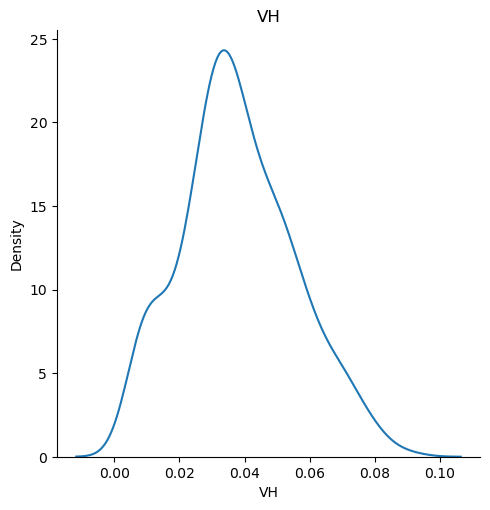

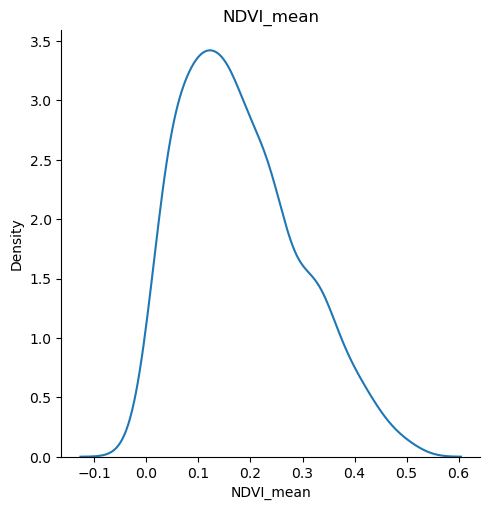

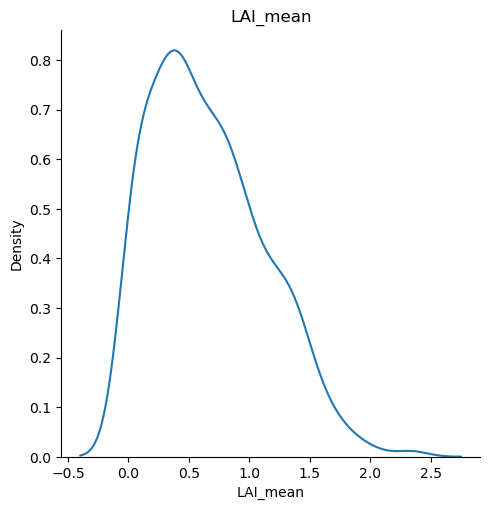

In [31]:
for indicator in ['Rice Yield (kg/ha)', 'RVI_mean', 'DPRVI_mean', 'VHVV_mean', 'VVVH_mean', 'VV', 'VH', 'NDVI_mean', 'LAI_mean']:
    sns.displot(data=circle_mask, x=indicator, kind="kde", palette='coolwarm')
    plt.title(indicator)

### Square

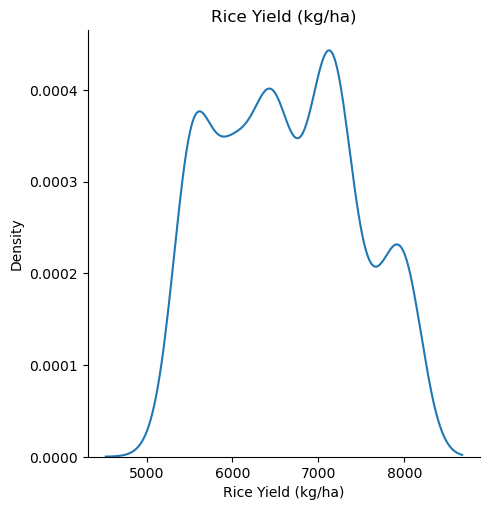

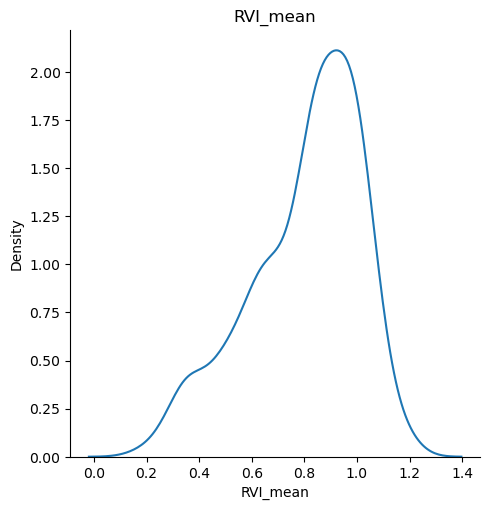

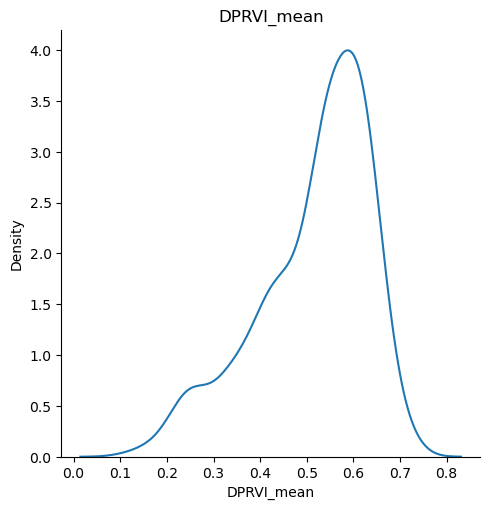

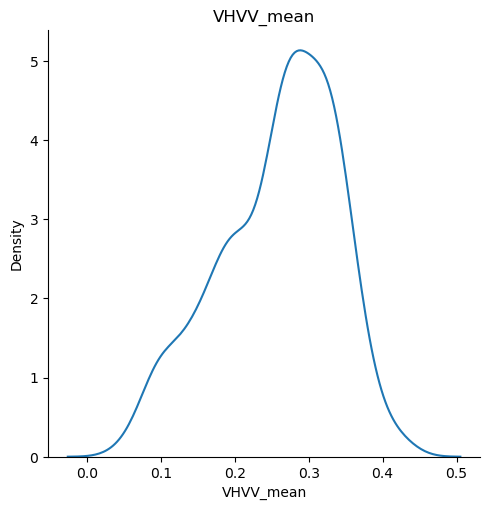

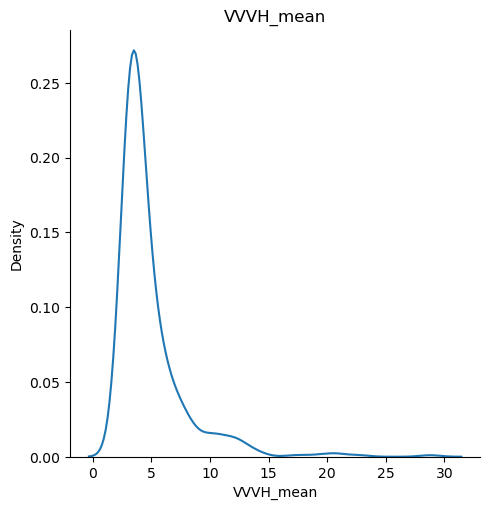

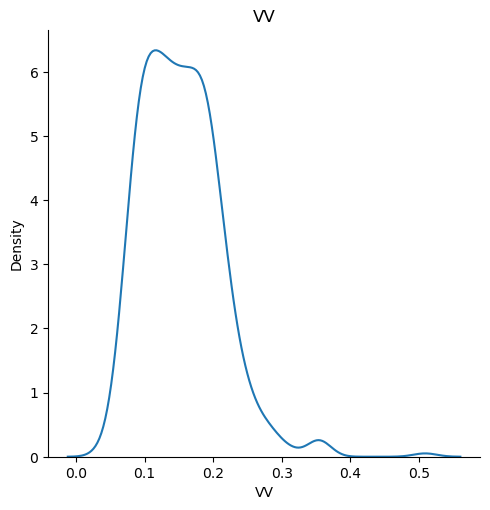

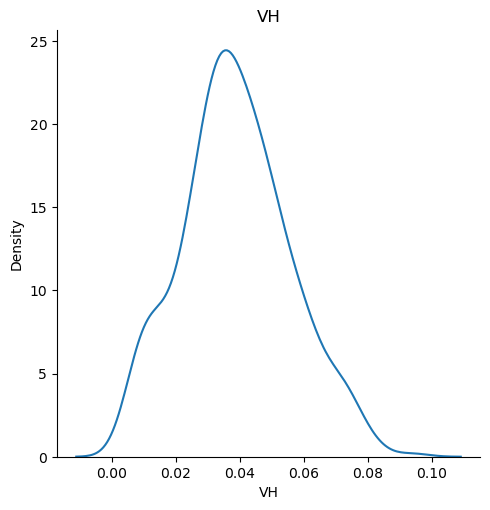

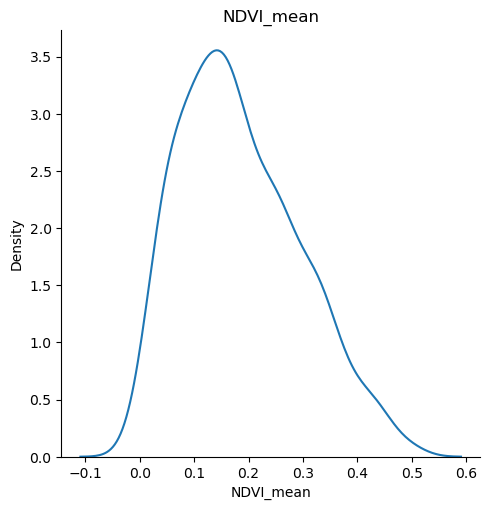

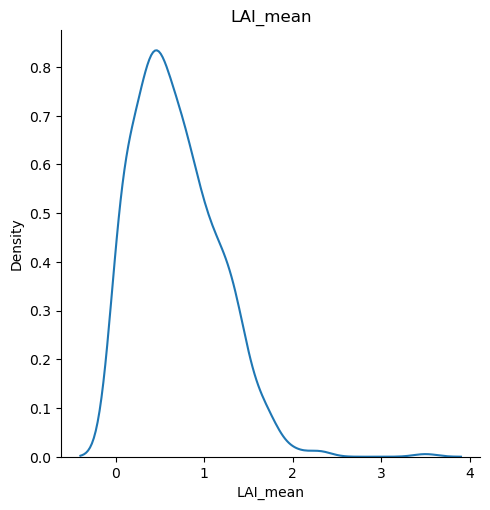

In [32]:
for indicator in ['Rice Yield (kg/ha)', 'RVI_mean', 'DPRVI_mean', 'VHVV_mean', 'VVVH_mean', 'VV', 'VH', 'NDVI_mean', 'LAI_mean']:
    sns.displot(data=square, x=indicator, kind="kde", palette='coolwarm')
    plt.title(indicator)

### Square mask

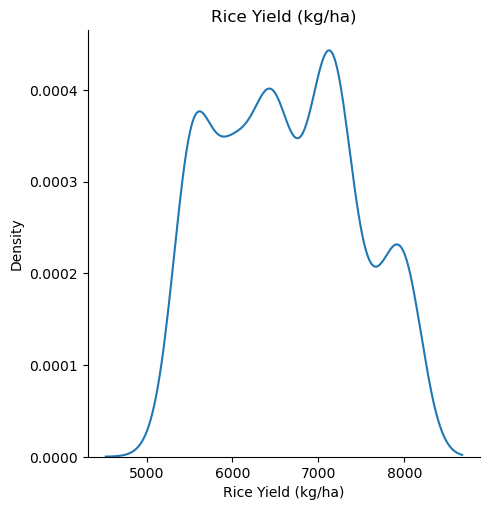

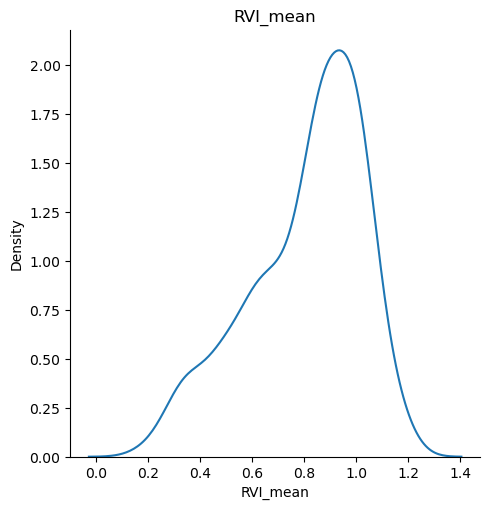

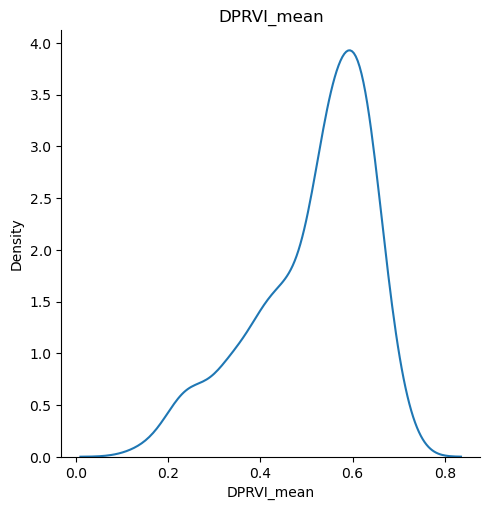

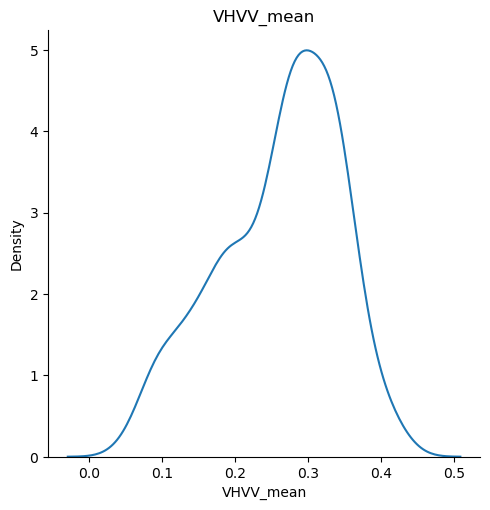

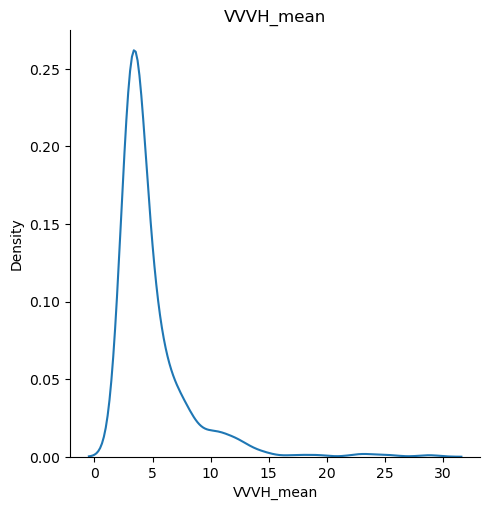

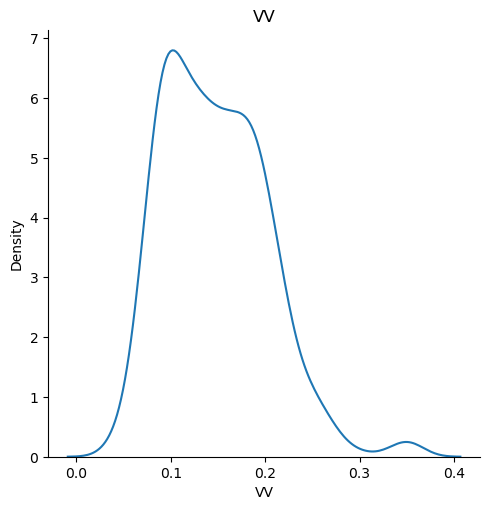

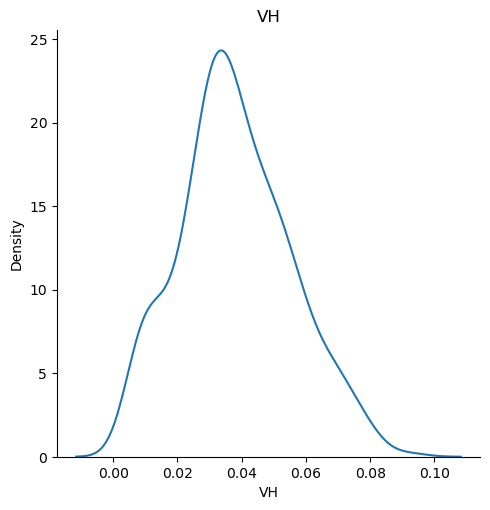

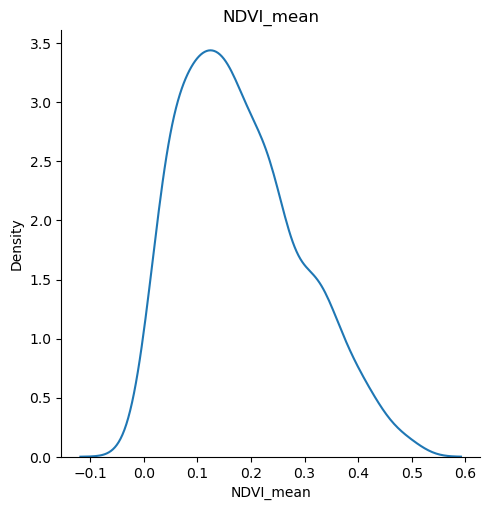

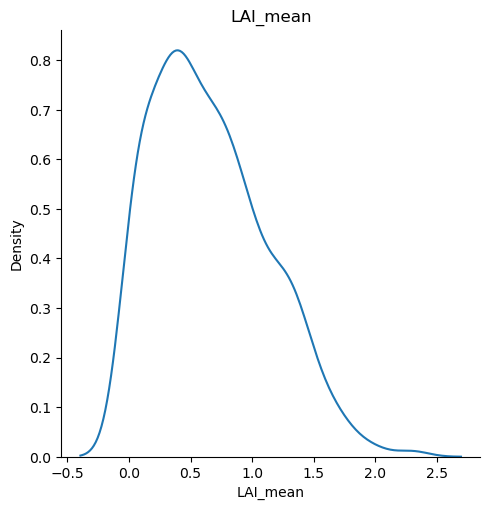

In [33]:
for indicator in ['Rice Yield (kg/ha)', 'RVI_mean', 'DPRVI_mean', 'VHVV_mean', 'VVVH_mean', 'VV', 'VH', 'NDVI_mean', 'LAI_mean']:
    sns.displot(data=square_mask, x=indicator, kind="kde", palette='coolwarm')
    plt.title(indicator)

## Modeling

In [34]:
import statsmodels.api as sm
import linearmodels as lm
from bs4 import BeautifulSoup
from stargazer.stargazer import Stargazer
from IPython.core.display import HTML

### Total

In [35]:
df_model = df_total[['Province', 'year', 'total_yield', 'NDVI_mean', 'LAI_mean']]
df_model = df_model.dropna().reset_index(drop=True)
df_model

,Province,year,total_yield,NDVI_mean,LAI_mean
0,Ha Noi,2016,56.3,0.264185,0.925865
1,Vinh Phuc,2016,50.4,0.288486,1.147428
2,Bac Ninh,2016,62.0,0.113689,0.502254
3,Quang Ninh,2016,50.1,0.212461,0.776852
4,Hai Duong,2016,60.4,0.114817,0.543988
...,...,...,...,...,...
422,Can Tho,2022,63.2,0.136192,0.456286
423,Hau Giang,2022,66.6,0.212779,0.769112
424,Soc Trang,2022,61.4,0.130949,0.407128
425,Bac Lieu,2022,63.4,0.177892,0.632293


In [36]:
Y = df_model['total_yield']

for x in ['NDVI_mean', 'LAI_mean']:
      print(x)
      X = sm.add_constant(df_model[x])
      model = sm.OLS(Y, X)
      results = model.fit(cov_type='HC1')
#       print(results.summary())
      print(round(results.rsquared, 4))
      print('\n')

NDVI_mean
0.0


LAI_mean
0.0155




In [37]:
year = pd.Categorical(df_model['year'])
X = df_model.set_index(['Province', 'year'])
X['year'] = year
Y = X['total_yield']
for x in ['NDVI_mean', 'LAI_mean']:
    print(x)
    model = lm.PanelOLS(Y, X[[x, 'year']], entity_effects=True)
    results = model.fit(cov_type='clustered', cluster_entity=True)

    # print(results.summary)
    print(round(results.rsquared, 4))
    print('\n')

# stargazer = Stargazer([full_log])
# HTML(stargazer.render_html())

NDVI_mean
0.3895


LAI_mean
0.3906




In [38]:
# year = pd.Categorical(df_model['year'])
# X = df_model.set_index(['Province', 'year'])
# X['year'] = year
# Y = X['total_production']
# for x in ['DPRVI_mean', 'RVI_mean', 'VH', 'VV', 'VHVV_mean',
#        'VVVH_mean']:
#     print(x)
    
#     model = lm.PanelOLS(Y, X[[x, 'year']], entity_effects=True)
#     results = model.fit(cov_type='clustered', cluster_entity=True)

#     print(results.summary)
#     print(round(results.rsquared, 4))

# stargazer = Stargazer([full_log])
# HTML(stargazer.render_html())

### Spring yield

#### All Spring

In [39]:
df_model = df_spring[['Province', 'year', 'spring_yield', 'NDVI_mean', 'LAI_mean']]
df_model = df_model.dropna().reset_index(drop=True)
df_model

,Province,year,spring_yield,NDVI_mean,LAI_mean
0,Ha Noi,2016,60.9,0.254127,0.823167
1,Vinh Phuc,2016,58.6,0.342175,1.372339
2,Bac Ninh,2016,65.0,0.034801,0.338341
3,Quang Ninh,2016,54.4,0.197903,0.604061
4,Hai Duong,2016,64.6,0.048906,0.374033
...,...,...,...,...,...
420,Can Tho,2022,74.2,0.100598,0.314180
421,Hau Giang,2022,77.8,0.238522,0.834253
422,Soc Trang,2022,67.1,0.100024,0.351862
423,Bac Lieu,2022,75.7,0.105605,0.323727


In [40]:
Y = df_model['spring_yield']

for x in ['NDVI_mean', 'LAI_mean']:
    X = sm.add_constant(df_model[x])
    model = sm.OLS(Y, X)
    results = model.fit(cov_type='HC1')

    print(x)
    print(round(results.rsquared, 4))
   #  print(results.summary())

NDVI_mean
0.0015
LAI_mean
0.0125


In [41]:
year = pd.Categorical(df_model['year'])
X = df_model.set_index(['Province', 'year'])
X['year'] = year
Y = X['spring_yield']
for x in ['NDVI_mean', 'LAI_mean']:
    
    model = lm.PanelOLS(Y, X[[x, 'year']], entity_effects=True)
    results = model.fit(cov_type='clustered', cluster_entity=True)

    # print(results.summary)
    print(x)
    print(round(results.rsquared, 4))

# stargazer = Stargazer([full_log])
# HTML(stargazer.render_html())

NDVI_mean
0.1606
LAI_mean
0.1573


#### Early Spring

In [42]:
df_model = df_early_spring[['Province', 'year', 'spring_yield', 'NDVI_mean', 'LAI_mean']]
df_model = df_model.dropna().reset_index(drop=True)
df_model

,Province,year,spring_yield,NDVI_mean,LAI_mean
0,Ha Noi,2016,60.9,0.307119,0.972223
1,Vinh Phuc,2016,58.6,0.491412,1.923471
2,Bac Ninh,2016,65.0,-0.013849,0.000000
3,Quang Ninh,2016,54.4,0.214384,0.730416
4,Hai Duong,2016,64.6,-0.007388,0.000000
...,...,...,...,...,...
420,Can Tho,2022,74.2,0.037480,0.000000
421,Hau Giang,2022,77.8,0.298125,0.908800
422,Soc Trang,2022,67.1,0.012986,0.000000
423,Bac Lieu,2022,75.7,0.086769,0.250483


In [43]:
year = pd.Categorical(df_model['year'])
X = df_model.set_index(['Province', 'year'])
X['year'] = year
Y = X['spring_yield']
for x in ['NDVI_mean', 'LAI_mean']:
    
    model = lm.PanelOLS(Y, X[[x, 'year']], entity_effects=True)
    results = model.fit(cov_type='clustered', cluster_entity=True)

    # print(results.summary)
    print(x)
    print(round(results.rsquared, 4))

# stargazer = Stargazer([full_log])
# HTML(stargazer.render_html())

NDVI_mean
0.1611
LAI_mean
0.159


#### Late Spring

In [44]:
df_model = df_late_spring[['Province', 'year', 'spring_yield', 'NDVI_mean', 'LAI_mean']]
df_model = df_model.dropna().reset_index(drop=True)
df_model

,Province,year,spring_yield,NDVI_mean,LAI_mean
0,Ha Noi,2016,60.9,0.201134,0.674111
1,Vinh Phuc,2016,58.6,0.192937,0.821207
2,Bac Ninh,2016,65.0,0.083451,0.676682
3,Quang Ninh,2016,54.4,0.181422,0.477705
4,Hai Duong,2016,64.6,0.105200,0.748067
...,...,...,...,...,...
418,Can Tho,2022,74.2,0.163716,0.628359
419,Hau Giang,2022,77.8,0.178919,0.759705
420,Soc Trang,2022,67.1,0.187062,0.703725
421,Bac Lieu,2022,75.7,0.124441,0.396972


In [45]:
year = pd.Categorical(df_model['year'])
X = df_model.set_index(['Province', 'year'])
X['year'] = year
Y = X['spring_yield']
for x in ['NDVI_mean', 'LAI_mean']:
    
    model = lm.PanelOLS(Y, X[[x, 'year']], entity_effects=True)
    results = model.fit(cov_type='clustered', cluster_entity=True)

    # print(results.summary)
    print(x)
    print(round(results.rsquared, 4))

# stargazer = Stargazer([full_log])
# HTML(stargazer.render_html())

NDVI_mean
0.1572
LAI_mean
0.1565


### Autumn yield

#### All Autumn

In [46]:
df_model = df_autumn[['Province', 'year', 'autumn_yield', 'NDVI_mean', 'LAI_mean']]
df_model = df_model.dropna().reset_index(drop=True)
df_model

,Province,year,autumn_yield,NDVI_mean,LAI_mean
0,Nghe An,2016,49.5,0.181196,0.731291
1,Ha Tinh,2016,45.4,0.206149,0.747925
2,Quang Binh,2016,41.0,0.171695,2.024293
3,Quang Tri,2016,51.8,0.276327,1.065951
4,Thua Thien Hue,2016,59.2,0.212035,0.682129
...,...,...,...,...,...
191,Can Tho,2022,57.2,0.165713,0.643241
192,Hau Giang,2022,58.9,0.231090,0.860064
193,Soc Trang,2022,54.7,0.211721,0.665957
194,Bac Lieu,2022,58.6,0.227415,0.922485


In [47]:
Y = df_model['autumn_yield']

for x in ['NDVI_mean', 'LAI_mean']:
    X = sm.add_constant(df_model[x])
    model = sm.OLS(Y, X)
    results = model.fit(cov_type='HC1')
   #  print(results.summary())
    print(x)
    print(round(results.rsquared, 4))

NDVI_mean
0.0194
LAI_mean
0.0015


In [48]:
year = pd.Categorical(df_model['year'])
X = df_model.set_index(['Province', 'year'])
X['year'] = year
Y = X['autumn_yield']
for x in ['NDVI_mean', 'LAI_mean']:
    
    model = lm.PanelOLS(Y, X[[x, 'year']], entity_effects=True)
    results = model.fit(cov_type='clustered', cluster_entity=True)

    # print(results.summary)
    print(x)
    print(round(results.rsquared, 4))

# stargazer = Stargazer([full_log])
# HTML(stargazer.render_html())

NDVI_mean
0.2393
LAI_mean
0.2411


#### Main Autumn

In [49]:
df_model = df_main_autumn[['Province', 'year', 'autumn_yield', 'NDVI_mean', 'LAI_mean']]
df_model = df_model.dropna().reset_index(drop=True)
df_model

,Province,year,autumn_yield,NDVI_mean,LAI_mean
0,Nghe An,2016,49.5,0.147617,0.697564
1,Ha Tinh,2016,45.4,0.202045,0.706450
2,Quang Binh,2016,41.0,0.172055,0.548586
3,Quang Tri,2016,51.8,0.327048,1.274207
4,Thua Thien Hue,2016,59.2,0.251554,0.795964
...,...,...,...,...,...
191,Can Tho,2022,57.2,0.151466,0.697193
192,Hau Giang,2022,58.9,0.264339,0.928088
193,Soc Trang,2022,54.7,0.280074,0.934669
194,Bac Lieu,2022,58.6,0.226640,0.989083


In [50]:
year = pd.Categorical(df_model['year'])
X = df_model.set_index(['Province', 'year'])
X['year'] = year
Y = X['autumn_yield']
for x in ['NDVI_mean', 'LAI_mean']:
    
    model = lm.PanelOLS(Y, X[[x, 'year']], entity_effects=True)
    results = model.fit(cov_type='clustered', cluster_entity=True)

    # print(results.summary)
    print(x)
    print(round(results.rsquared, 4))

# stargazer = Stargazer([full_log])
# HTML(stargazer.render_html())

NDVI_mean
0.238
LAI_mean
0.2377


#### Late Autumn

In [51]:
df_model = df_late_autumn[['Province', 'year', 'autumn_yield', 'NDVI_mean', 'LAI_mean']]
df_model = df_model.dropna().reset_index(drop=True)
df_model

,Province,year,autumn_yield,NDVI_mean,LAI_mean
0,Nghe An,2016,49.5,0.214775,0.765018
1,Ha Tinh,2016,45.4,0.210254,0.789401
2,Quang Binh,2016,41.0,0.171336,3.500000
3,Quang Tri,2016,51.8,0.225605,0.857696
4,Thua Thien Hue,2016,59.2,0.172516,0.568294
...,...,...,...,...,...
191,Can Tho,2022,57.2,0.179961,0.589289
192,Hau Giang,2022,58.9,0.197840,0.792040
193,Soc Trang,2022,54.7,0.143368,0.397246
194,Bac Lieu,2022,58.6,0.228189,0.855887


In [52]:
year = pd.Categorical(df_model['year'])
X = df_model.set_index(['Province', 'year'])
X['year'] = year
Y = X['autumn_yield']
for x in ['NDVI_mean', 'LAI_mean']:
    
    model = lm.PanelOLS(Y, X[[x, 'year']], entity_effects=True)
    results = model.fit(cov_type='clustered', cluster_entity=True)

    # print(results.summary)
    print(x)
    print(round(results.rsquared, 4))

# stargazer = Stargazer([full_log])
# HTML(stargazer.render_html())

NDVI_mean
0.2411
LAI_mean
0.242


### Winter yield

In [53]:
df_model = df_winter[['Province', 'year', 'winter_yield', 'NDVI_mean', 'LAI_mean']]
df_model = df_model.dropna().reset_index(drop=True)
df_model

,Province,year,winter_yield,NDVI_mean,LAI_mean
0,Ha Noi,2016,51.6,0.364874,1.147018
1,Vinh Phuc,2016,41.1,0.271694,0.967005
2,Bac Ninh,2016,59.0,0.093550,0.472116
3,Quang Ninh,2016,47.2,0.245534,0.932132
4,Hai Duong,2016,56.1,0.022735,0.000000
...,...,...,...,...,...
387,An Giang,2022,42.1,0.197822,0.897128
388,Kien Giang,2022,53.8,0.106173,0.000000
389,Soc Trang,2022,50.9,0.031254,0.000000
390,Bac Lieu,2022,60.7,0.223420,0.669040


In [54]:
Y = df_model['winter_yield']

for x in ['NDVI_mean', 'LAI_mean']:
    X = sm.add_constant(df_model[x])
    model = sm.OLS(Y, X)
    results = model.fit(cov_type='HC1')
   #  print(results.summary())
    print(x)
    print(round(results.rsquared, 4))

NDVI_mean
0.0411
LAI_mean
0.0089


In [55]:
year = pd.Categorical(df_model['year'])
X = df_model.set_index(['Province', 'year'])
X['year'] = year
Y = X['winter_yield']
for x in ['NDVI_mean', 'LAI_mean']:
    
    model = lm.PanelOLS(Y, X[[x, 'year']], entity_effects=True)
    results = model.fit(cov_type='clustered', cluster_entity=True)

    # print(results.summary)
    print(x)
    print(round(results.rsquared, 4))

# stargazer = Stargazer([full_log])
# HTML(stargazer.render_html())

NDVI_mean
0.2523
LAI_mean
0.2459


## EY

### Circle

In [93]:
df_model = circle[['Rice Yield (kg/ha)', 'RVI_mean', 'DPRVI_mean', 'VHVV_mean', 'VVVH_mean', 'VV', 'VH', 'NDVI_mean', 'LAI_mean', 'Season(SA = Summer Autumn, WS = Winter Spring)', 'Rice Crop Intensity(D=Double, T=Triple)']]
df_model = df_model.rename({'Season(SA = Summer Autumn, WS = Winter Spring)': 'season'}, axis=1)
df_model['season'] = df_model['season'].replace({'SA': 0,
                                                 'WS': 1})
df_model = df_model.dropna().reset_index(drop=True)
df_model

,Rice Yield (kg/ha),RVI_mean,DPRVI_mean,VHVV_mean,VVVH_mean,VV,VH,NDVI_mean,LAI_mean,season,"Rice Crop Intensity(D=Double, T=Triple)"
0,5500,0.951877,0.599957,0.313077,3.227055,0.106204,0.032965,0.430582,1.772754,0,T
1,6000,1.133099,0.688630,0.396190,2.546242,0.107096,0.041972,0.452296,1.629166,0,T
2,6400,0.910667,0.578708,0.295473,3.417874,0.099430,0.029023,0.242516,0.905116,0,D
3,6000,1.046084,0.647383,0.354620,2.835043,0.091708,0.032354,0.386807,1.540181,0,T
4,6400,1.109895,0.678336,0.384167,2.606378,0.085355,0.032756,0.309851,1.187968,0,D
...,...,...,...,...,...,...,...,...,...,...,...
444,6640,0.825069,0.532865,0.260710,3.898743,0.207433,0.053997,0.145922,0.374240,1,T
445,7200,0.654620,0.436828,0.196161,5.181141,0.114353,0.022483,0.072725,0.116627,1,T
446,7200,0.332614,0.234606,0.091343,14.365927,0.590093,0.021335,0.107263,0.282199,1,T
447,6400,0.367488,0.257597,0.101936,10.627235,0.083774,0.008633,0.078008,0.221879,1,T


In [94]:
Y = df_model['Rice Yield (kg/ha)']

for x in ['RVI_mean', 'DPRVI_mean', 'VHVV_mean', 'VVVH_mean', 'VV', 'VH', 'NDVI_mean', 'LAI_mean']:
    X = sm.add_constant(df_model[x])
    model = sm.OLS(Y, X)
    results = model.fit(cov_type='HC1')
   #  print(results.summary())
    print(x)
    print(round(results.rsquared, 4))

RVI_mean
0.0081
DPRVI_mean
0.0091
VHVV_mean
0.0067
VVVH_mean
0.0174
VV
0.0267
VH
0.0308
NDVI_mean
0.0215
LAI_mean
0.0569


In [97]:
season = pd.Categorical(df_model['season'])
X = df_model.set_index(['Rice Crop Intensity(D=Double, T=Triple)', 'season'])
X['season'] = season
Y = X['Rice Yield (kg/ha)']
for x in ['RVI_mean', 'DPRVI_mean', 'VHVV_mean', 'VVVH_mean', 'VV', 'VH', 'NDVI_mean', 'LAI_mean']:
    
    model = lm.PanelOLS(Y, X[[x, 'season']], entity_effects=True)
    results = model.fit(cov_type='clustered', cluster_entity=True)

    # print(results.summary)
    print(x)
    print(round(results.rsquared, 4))

RVI_mean
0.611
DPRVI_mean
0.611
VHVV_mean
0.611
VVVH_mean
0.6111
VV
0.6123
VH
0.6115
NDVI_mean
0.6118
LAI_mean
0.6121


### Circle mask

In [98]:
df_model = circle_mask[['Rice Yield (kg/ha)', 'RVI_mean', 'DPRVI_mean', 'VHVV_mean', 'VVVH_mean', 'VV', 'VH', 'NDVI_mean', 'LAI_mean', 'Season(SA = Summer Autumn, WS = Winter Spring)', 'Rice Crop Intensity(D=Double, T=Triple)']]
df_model = df_model.rename({'Season(SA = Summer Autumn, WS = Winter Spring)': 'season'}, axis=1)
df_model['season'] = df_model['season'].replace({'SA': 0,
                                                 'WS': 1})
df_model = df_model.dropna().reset_index(drop=True)
df_model

,Rice Yield (kg/ha),RVI_mean,DPRVI_mean,VHVV_mean,VVVH_mean,VV,VH,NDVI_mean,LAI_mean,season,"Rice Crop Intensity(D=Double, T=Triple)"
0,5500,0.957812,0.602964,0.315671,3.201863,0.105893,0.033120,0.432629,1.782829,0,T
1,6000,1.158094,0.700198,0.408517,2.469047,0.097540,0.039591,0.461005,1.676711,0,T
2,6400,0.920827,0.584047,0.299700,3.366875,0.097505,0.028900,0.241997,0.920174,0,D
3,6000,1.051434,0.649936,0.357149,2.817187,0.091231,0.032410,0.387449,1.550127,0,T
4,6400,1.109895,0.678336,0.384167,2.606378,0.085355,0.032756,0.309851,1.187968,0,D
...,...,...,...,...,...,...,...,...,...,...,...
444,6640,0.825069,0.532865,0.260710,3.898743,0.207433,0.053997,0.145922,0.374240,1,T
445,7200,0.654620,0.436828,0.196161,5.181141,0.114353,0.022483,0.072725,0.116627,1,T
446,7200,0.343162,0.242163,0.094164,11.043572,0.181929,0.015543,0.098247,0.244979,1,T
447,6400,0.362599,0.254266,0.100531,10.847863,0.081510,0.008270,0.071234,0.199494,1,T


In [99]:
Y = df_model['Rice Yield (kg/ha)']

for x in ['RVI_mean', 'DPRVI_mean', 'VHVV_mean', 'VVVH_mean', 'VV', 'VH', 'NDVI_mean', 'LAI_mean']:
    X = sm.add_constant(df_model[x])
    model = sm.OLS(Y, X)
    results = model.fit(cov_type='HC1')
   #  print(results.summary())
    print(x)
    print(round(results.rsquared, 4))

RVI_mean
0.0086
DPRVI_mean
0.0097
VHVV_mean
0.0073
VVVH_mean
0.0176
VV
0.0266
VH
0.0304
NDVI_mean
0.0236
LAI_mean
0.0588


In [100]:
season = pd.Categorical(df_model['season'])
X = df_model.set_index(['Rice Crop Intensity(D=Double, T=Triple)', 'season'])
X['season'] = season
Y = X['Rice Yield (kg/ha)']
for x in ['RVI_mean', 'DPRVI_mean', 'VHVV_mean', 'VVVH_mean', 'VV', 'VH', 'NDVI_mean', 'LAI_mean']:
    
    model = lm.PanelOLS(Y, X[[x, 'season']], entity_effects=True)
    results = model.fit(cov_type='clustered', cluster_entity=True)

    # print(results.summary)
    print(x)
    print(round(results.rsquared, 4))

RVI_mean
0.611
DPRVI_mean
0.611
VHVV_mean
0.611
VVVH_mean
0.6111
VV
0.6115
VH
0.6112
NDVI_mean
0.6118
LAI_mean
0.612


### Square

In [101]:
df_model = square[['Rice Yield (kg/ha)', 'RVI_mean', 'DPRVI_mean', 'VHVV_mean', 'VVVH_mean', 'VV', 'VH', 'NDVI_mean', 'LAI_mean', 'Season(SA = Summer Autumn, WS = Winter Spring)', 'Rice Crop Intensity(D=Double, T=Triple)']]
df_model = df_model.rename({'Season(SA = Summer Autumn, WS = Winter Spring)': 'season'}, axis=1)
df_model['season'] = df_model['season'].replace({'SA': 0,
                                                 'WS': 1})
df_model = df_model.dropna().reset_index(drop=True)
df_model

,Rice Yield (kg/ha),RVI_mean,DPRVI_mean,VHVV_mean,VVVH_mean,VV,VH,NDVI_mean,LAI_mean,season,"Rice Crop Intensity(D=Double, T=Triple)"
0,5500,0.954135,0.601073,0.314098,3.218257,0.105420,0.032817,0.427994,1.767252,0,T
1,6000,1.126301,0.685386,0.392966,2.569620,0.108432,0.042152,0.453491,1.640833,0,T
2,6400,0.913196,0.579902,0.296676,3.410440,0.099680,0.029129,0.245299,0.918614,0,D
3,6000,1.045605,0.647045,0.354532,2.839597,0.091684,0.032254,0.384321,1.543912,0,T
4,6400,1.102469,0.674718,0.380749,2.633365,0.087091,0.033020,0.312784,1.201021,0,D
...,...,...,...,...,...,...,...,...,...,...,...
444,6640,0.812911,0.526115,0.256013,3.981378,0.208287,0.053204,0.143962,0.363516,1,T
445,7200,0.656164,0.437806,0.196653,5.157477,0.118037,0.023388,0.072734,0.114878,1,T
446,7200,0.360032,0.252367,0.099874,13.089638,0.509009,0.021770,0.112675,0.303488,1,T
447,6400,0.380556,0.265801,0.106186,10.375514,0.084239,0.009132,0.079279,0.226501,1,T


In [102]:
Y = df_model['Rice Yield (kg/ha)']

for x in ['RVI_mean', 'DPRVI_mean', 'VHVV_mean', 'VVVH_mean', 'VV', 'VH', 'NDVI_mean', 'LAI_mean']:
    X = sm.add_constant(df_model[x])
    model = sm.OLS(Y, X)
    results = model.fit(cov_type='HC1')
   #  print(results.summary())
    print(x)
    print(round(results.rsquared, 4))

RVI_mean
0.0081
DPRVI_mean
0.0091
VHVV_mean
0.0067
VVVH_mean
0.0183
VV
0.03
VH
0.0325
NDVI_mean
0.0213
LAI_mean
0.0573


In [103]:
season = pd.Categorical(df_model['season'])
X = df_model.set_index(['Rice Crop Intensity(D=Double, T=Triple)', 'season'])
X['season'] = season
Y = X['Rice Yield (kg/ha)']
for x in ['RVI_mean', 'DPRVI_mean', 'VHVV_mean', 'VVVH_mean', 'VV', 'VH', 'NDVI_mean', 'LAI_mean']:
    
    model = lm.PanelOLS(Y, X[[x, 'season']], entity_effects=True)
    results = model.fit(cov_type='clustered', cluster_entity=True)

    # print(results.summary)
    print(x)
    print(round(results.rsquared, 4))

RVI_mean
0.611
DPRVI_mean
0.611
VHVV_mean
0.611
VVVH_mean
0.6113
VV
0.6128
VH
0.6115
NDVI_mean
0.6118
LAI_mean
0.6121


### Square Mask

In [104]:
df_model = square_mask[['Rice Yield (kg/ha)', 'RVI_mean', 'DPRVI_mean', 'VHVV_mean', 'VVVH_mean', 'VV', 'VH', 'NDVI_mean', 'LAI_mean', 'Season(SA = Summer Autumn, WS = Winter Spring)', 'Rice Crop Intensity(D=Double, T=Triple)']]
df_model = df_model.rename({'Season(SA = Summer Autumn, WS = Winter Spring)': 'season'}, axis=1)
df_model['season'] = df_model['season'].replace({'SA': 0,
                                                 'WS': 1})
df_model = df_model.dropna().reset_index(drop=True)
df_model

,Rice Yield (kg/ha),RVI_mean,DPRVI_mean,VHVV_mean,VVVH_mean,VV,VH,NDVI_mean,LAI_mean,season,"Rice Crop Intensity(D=Double, T=Triple)"
0,5500,0.959100,0.603583,0.316274,3.197364,0.105106,0.032929,0.429219,1.773994,0,T
1,6000,1.151956,0.697372,0.405470,2.487540,0.100316,0.040390,0.461346,1.684585,0,T
2,6400,0.921737,0.584378,0.300245,3.368079,0.098133,0.029039,0.245147,0.932224,0,D
3,6000,1.054199,0.651209,0.358518,2.808927,0.090286,0.032134,0.385130,1.556989,0,T
4,6400,1.102469,0.674718,0.380749,2.633365,0.087091,0.033020,0.312784,1.201021,0,D
...,...,...,...,...,...,...,...,...,...,...,...
444,6640,0.812911,0.526115,0.256013,3.981378,0.208287,0.053204,0.143962,0.363516,1,T
445,7200,0.656164,0.437806,0.196653,5.157477,0.118037,0.023388,0.072734,0.114878,1,T
446,7200,0.363072,0.254929,0.100446,10.553486,0.170471,0.015564,0.098764,0.242741,1,T
447,6400,0.377561,0.263700,0.105368,10.538389,0.082702,0.008909,0.074505,0.210779,1,T


In [105]:
Y = df_model['Rice Yield (kg/ha)']

for x in ['RVI_mean', 'DPRVI_mean', 'VHVV_mean', 'VVVH_mean', 'VV', 'VH', 'NDVI_mean', 'LAI_mean']:
    X = sm.add_constant(df_model[x])
    model = sm.OLS(Y, X)
    results = model.fit(cov_type='HC1')
   #  print(results.summary())
    print(x)
    print(round(results.rsquared, 4))

RVI_mean
0.0086
DPRVI_mean
0.0096
VHVV_mean
0.0073
VVVH_mean
0.0183
VV
0.029
VH
0.0321
NDVI_mean
0.0234
LAI_mean
0.0592


In [106]:
season = pd.Categorical(df_model['season'])
X = df_model.set_index(['Rice Crop Intensity(D=Double, T=Triple)', 'season'])
X['season'] = season
Y = X['Rice Yield (kg/ha)']
for x in ['RVI_mean', 'DPRVI_mean', 'VHVV_mean', 'VVVH_mean', 'VV', 'VH', 'NDVI_mean', 'LAI_mean']:
    
    model = lm.PanelOLS(Y, X[[x, 'season']], entity_effects=True)
    results = model.fit(cov_type='clustered', cluster_entity=True)

    # print(results.summary)
    print(x)
    print(round(results.rsquared, 4))

RVI_mean
0.611
DPRVI_mean
0.611
VHVV_mean
0.611
VVVH_mean
0.6112
VV
0.6118
VH
0.6113
NDVI_mean
0.6117
LAI_mean
0.6119
